# Задание
1.	Какой клиент совершил больше всего успешных операций? (success == True)
2.	С какой платформы осуществляется наибольшее количество успешных операций?
3.	Какую платформу предпочитают премиумные клиенты?
4.	Визуализируйте распределение возраста клиентов в зависимости от типа клиента (премиум или нет)
5.	Постройте график распределения числа успешных операций
6.	Визуализируйте число успешных операций, сделанных на платформе computer, в зависимости от возраста, используя sns.countplot (x – возраст, y – число успешных операций). Клиенты какого возраста совершили наибольшее количество успешных действий?

Описание данных таблица user_data:
•	client – идентификатор пользователя
•	premium – является ли клиент премиум
•	age – возраст

Описание данных таблица logs:
•	client – идентификатор пользователя
•	success – результат (успех - 1, нет - 0)
•	platform – платформа
•	time – время в формате Unix

# Чтение и анализ танных

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
logs = pd.read_csv(r"C:\Users\Станислав\Desktop\личное\Мои_проекты\client_operations_analysis\data\logs.csv")

In [36]:
user_data = pd.read_csv(r"C:\Users\Станислав\Desktop\личное\Мои_проекты\client_operations_analysis\data\user_data.csv")

In [37]:
logs.head(5)

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629


In [38]:
print(f'Количество уникальных значений \n{logs.nunique()}')

Количество уникальных значений 
client      4011
success        2
platform       3
time        4376
dtype: int64


In [39]:
user_data.head(5)

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [40]:
# Объединение таблиц
full_df = pd.merge(logs, user_data, how = 'inner',on = ['client'])

In [41]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3439 entries, 0 to 3438
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   client    3439 non-null   int64 
 1   success   3439 non-null   bool  
 2   platform  3439 non-null   object
 3   time      3439 non-null   int64 
 4   premium   3439 non-null   bool  
 5   age       3439 non-null   int64 
dtypes: bool(2), int64(3), object(1)
memory usage: 114.3+ KB


In [42]:
full_df.head(5)

,client,success,platform,time,premium,age
0,61468,True,phone,1585425658,False,25
1,35604,False,phone,1585459894,True,65
2,10931,True,computer,1585468629,False,28
3,41928,True,phone,1585446772,False,46
4,48925,True,phone,1585467880,False,33


# Задание 1: Клиент с наибольшим числом успешных операций

In [43]:
# Оставляем только успешные операции, фильтруя столбцец ['success']==True]
group_client_success = full_df[full_df['success']==True]

In [44]:
# Группируем по клиентам и агрегируем данные  (считаем количество успешных операций по каждому клиенту)
group_client_success = group_client_success.groupby('client')['success'].count().reset_index()

In [45]:
# Группируем по количеству совершенных операций и формируем список клиентов в каждой группе заказов 
top_client = group_client_success.groupby('success').agg(
    client_list =('client', lambda x : ', '.join(map(str, sorted(x))))
).reset_index()

In [46]:
top_client

,success,client_list
0,1,"40, 75, 81, 132, 164, 278, 316, 405, 492, 624,..."
1,2,"2249, 3936, 6888, 8910, 12438, 13204, 17476, 1..."
2,3,79320
3,40,64064
4,41,"12179, 28719, 36165, 52870, 61468, 61473, 7834..."


In [47]:
top_client = top_client[top_client['success'] == 41]
top_client =top_client['client_list'].iloc[0]

In [48]:
print(f'Клиенты с наибольшим количеством заказов: {top_client}')

Клиенты с наибольшим количеством заказов: 12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584


## **Вывод:** 
Клиенты 12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584 совершили по 41 успешной операции — это лидеры.

# Задание 2: Лучшая платформа по успешным операциям

In [49]:
top_platform = full_df[full_df['success'] == 1]

In [50]:
top_platform = top_platform.groupby('platform')['success'].count().reset_index().sort_values(by='success', ascending=False)

In [51]:
top_platform

,platform,success
1,phone,1565
0,computer,843
2,tablet,139


In [52]:
top1_platform = top_platform['platform'].iloc[0]
top_value    = top_platform['success'].iloc[0]
print(f'Топ 1 платформа "{top1_platform}" на ней было сделано {top_value} - заказов')

Топ 1 платформа "phone" на ней было сделано 1565 - заказов


## **Вывод:** 
Платформа `phone` лидирует с большим отрывом — 1565 успешные заказов.

# Задание 3: Предпочтения премиум-клиентов

In [53]:
premium_platform = full_df[full_df['premium'] == 1]

In [54]:
premium_platform = premium_platform.groupby('platform').agg(
    uniq_clients = ('client','nunique')
).sort_values(by = ['uniq_clients'], ascending= False).reset_index()

In [55]:
premium_platform

,platform,uniq_clients
0,phone,242
1,computer,145
2,tablet,24


In [56]:
top1_premium_platform = premium_platform['platform'].iloc[0]
uniq_users            = premium_platform['uniq_clients'].iloc[0]
print(f'Самая популярная платформа "{top1_premium_platform}" на ней было зарегестрированно - {uniq_users} пользователя')

Самая популярная платформа "phone" на ней было зарегестрированно - 242 пользователя


## **Вывод:** 
Среди премиум-клиентов платформа `phone` также лидирует (242 уникальных пользователя).

# Задание 4: Распределение возраста по типам клиентов

In [57]:
full_df.head(5)
df_plot = full_df.copy()

In [58]:
df_plot['premium'] = df_plot['premium'].map({True : 'Премиальные_клиенты',False : 'Обычные_клиенты'})

Text(0, 0.5, 'Плотность')

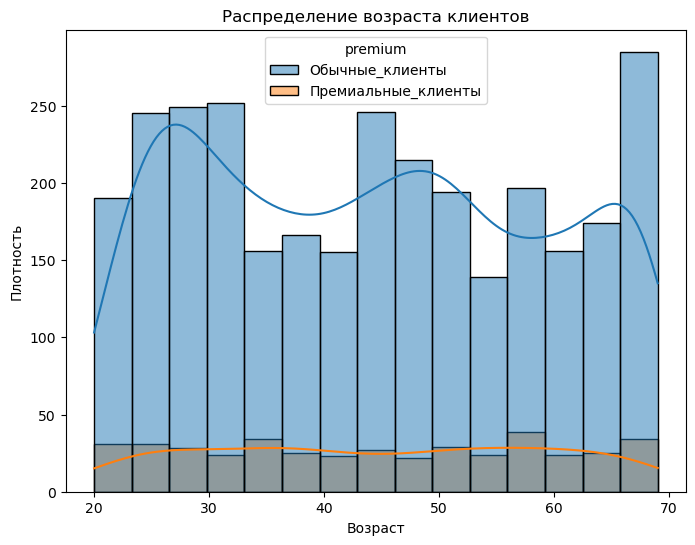

In [59]:
plt.figure(figsize=(8,6))
sns.histplot(df_plot, x = 'age', hue= 'premium', kde=True, stat='count')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Плотность')

## **Вывод:**
 Премиум-клиенты (оранжевый цвет): Распределены по возрасту очень равномерно от 20 до 68 лет. Явных пиков или перекосов в какую-то одну возрастную группу нет. Продукт интересен премиум-пользователям любого возраста.
 
 
 Обычные клиенты (синий цвет): Здесь распределение волнообразное. Четко видны три группы активности: молодые люди (25–30 лет), клиенты среднего возраста (около 45 лет) и самый высокий пик — пожилые люди (старше 65 лет).

# Задание 5: Распределение числа успешных операций

In [60]:
df_plot_2 = group_client_success.sort_values(by='success', ascending=False).copy()

In [61]:
df_plot_2

,client,success
250,12179,41
737,36165,41
588,28719,41
1280,61473,41
1279,61468,41
...,...,...
702,34642,1
701,34640,1
700,34630,1
699,34615,1


Text(0, 0.5, 'Количество клиентов')

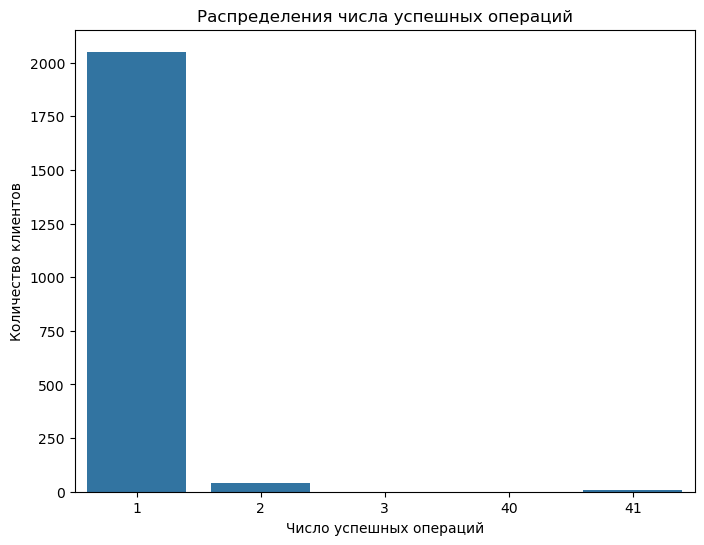

In [62]:
plt.figure(figsize=(8,6))
sns.countplot(df_plot_2, x ='success')
plt.title('Распределения числа успешных операций')
plt.xlabel('Число успешных операций')
plt.ylabel('Количество клиентов')

## Вывод:

Подавляющее большинство клиентов (более 2000 человек) совершают всего по 1–2 успешные операции. Это основная масса пользователей платформы.

Обнаружена группа аномально активных клиентов: в данных присутствует небольшое число пользователей (9 человек), каждый из которых совершил ровно 41 успешную операцию.

Промежуточные значения отсутствуют: на отрезках от 3 до 40 операций активность пользователей практически нулевая.

# Задание 6
Визуализируйте число успешных операций, сделанных на платформе computer, в зависимости от возраста, используя sns.countplot (x – возраст, y – число успешных операций). Клиенты какого возраста совершили наибольшее количество успешных действий?

In [63]:
df_plot_computer = full_df.copy()

In [64]:
df_plot_computer = df_plot_computer[(df_plot_computer['platform']== 'computer') & (df_plot_computer['success']== True)]

In [65]:
df_plot_computer.head(5)

,client,success,platform,time,premium,age
2,10931,True,computer,1585468629,False,28
5,32167,True,computer,1585457972,False,42
7,71087,True,computer,1585458446,False,36
10,39975,True,computer,1585428343,False,69
11,99308,True,computer,1585409409,True,38


Text(0, 0.5, 'Количество успешных операций')

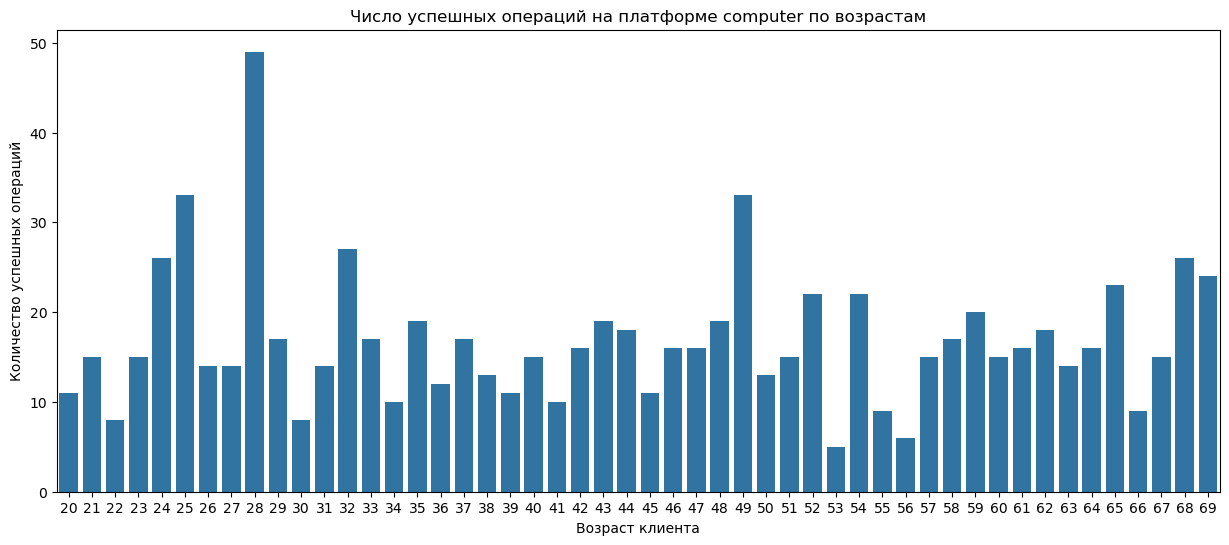

In [66]:
plt.figure(figsize=(15,6))
sns.countplot(df_plot_computer, x='age')
plt.title('Число успешных операций на платформе computer по возрастам')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество успешных операций')

## Вывод:

Абсолютный лидер по активности: Максимальное количество успешных операций на компьютерах совершают клиенты в возрасте 28 лет (выраженный пик, около 49 операций).

Дополнительные пики активности: Также повышенный интерес к платформе заметен у молодых людей в возрасте 25 лет и зрелых клиентов в возрасте 49 лет (оба пика — выше 30 операций).

Общая тенденция: В остальных возрастных группах (как среди молодых, так и среди пожилых) активность держится на стабильном среднем уровне — примерно от 10 до 20 успешных операций для каждого возраста.